In [1]:
import warnings
warnings.filterwarnings('ignore')

from functions import *


from scipy.stats import linregress
import matplotlib.colors as mcolors

import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns
import pandas as pd
import numpy as np

palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = { 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
benchmark_subsample = df[(df.dist<1.5) & (df.Av<0.5)]



<>:26: SyntaxWarning: invalid escape sequence '\d'
<>:26: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Ruan\AppData\Local\Temp\ipykernel_7096\2354293413.py:26: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv('Dados\data.csv', index_col='Cluster')


In [2]:
print(df[['bin_frac_corr','bin_frac_05_corr',]].describe().round(2).T)

                  count  mean   std   min   25%   50%   75%   max
bin_frac_corr     771.0  0.55  0.07  0.28  0.52  0.55  0.60  0.75
bin_frac_05_corr  771.0  0.37  0.06  0.18  0.33  0.37  0.41  0.60


In [11]:
df.columns

Index(['Cluster.1', 'RA_ICRS', 'DE_ICRS', 'dist', 'e_dist', 'age', 'e_age',
       'FeH', 'e_FeH', 'Av', 'e_Av', 'Nc', 'alpha_high_int',
       'alpha_high_er_int', 'alpha_low_int', 'alpha_low_er_int', 'Mc_int',
       'Mc_er_int', 'offset_int', 'offset_er_int', 'mass_total',
       'e_mass_total', 'bin_frac', 'average_ratio', 'str_average_ratio',
       'segr_ratio', 'segr_ratio_std', 'mass_seg', 'mass_seg_pval',
       'bin_frac_05', 'n_members', 'rh', 'e_rh', 't_relax', 'e_t_relax', 'tau',
       'e_tau', 'bin_frac_ref', 'bin_frac_ref_05', 'n_systems',
       'bin_frac_corr', 'e_bin_frac', 'bin_frac_05_corr', 'e_bin_frac_05'],
      dtype='object')

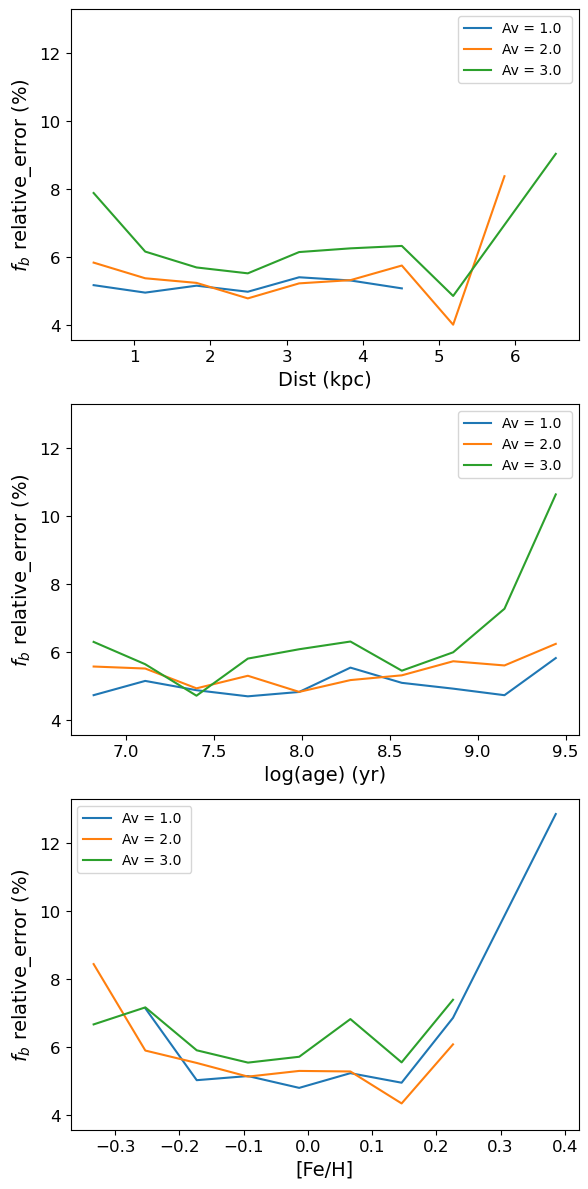

In [14]:
fig, axs = plt.subplots(3,1, figsize = (6,12), sharey=True)
aux = df.copy(deep=True)
aux['relative_error'] = aux['e_bin_frac']
# Agrupamento por faixas de extinção Av
aux['Av_group'] = pd.cut(aux['Av'], bins=[0, 1.0, 2.0, 3.0,], 
                         labels=['Av = 1.0 ', 'Av = 2.0', 'Av = 3.0',])

# Divide a variável 'dist' (distância) em 10 faixas
aux['dist_bin'] = pd.cut(aux['dist'], bins=10)
aux['dist_center'] = aux['dist_bin'].apply(lambda x: x.mid)

# Agrupa por faixa de dist e grupo de Av, calcula média de e_bin_frac

grouped = aux.groupby(['Av_group', 'dist_center'])['relative_error'].agg(['mean',]).reset_index()
sns.lineplot(data=grouped, x='dist_center', y=grouped['mean']*100, hue='Av_group', ax= axs[0])
axs[0].set_xlabel(r'Dist (kpc)', fontdict=font)



aux['age_bin'] = pd.cut(aux['age'], bins=10)
aux['age_center'] = aux['age_bin'].apply(lambda x: x.mid)


grouped = aux.groupby(['Av_group', 'age_center'])['relative_error'].agg(['mean',]).reset_index()
grouped['mean'] = grouped['mean']


sns.lineplot(data=grouped, x='age_center', y=grouped['mean']*100, hue='Av_group', ax= axs[1])
axs[1].set_xlabel(r'log(age) (yr)', fontdict=font)

aux['FeH_bin'] = pd.cut(aux['FeH'], bins=10)
aux['FeH_center'] = aux['FeH_bin'].apply(lambda x: x.mid)

grouped = aux.groupby(['Av_group', 'FeH_center'])['relative_error'].agg(['mean',]).reset_index()
sns.lineplot(data=grouped, x='FeH_center', y=grouped['mean']*100, hue='Av_group', ax= axs[2])
axs[2].set_xlabel(r'[Fe/H]', fontdict=font)

axs[0].set_ylabel(r'$f_b$ relative_error (%)', fontdict= font)
axs[1].set_ylabel(r'$f_b$ relative_error (%)', fontdict= font)
axs[2].set_ylabel(r'$f_b$ relative_error (%)', fontdict= font)

for ax in axs:
    ax.tick_params(labelsize=labelsize)
    ax.legend(fontsize=10)

plt.tight_layout()
#plt.savefig('Figures/err_fb.png',bbox_inches='tight', dpi=300)
plt.show()


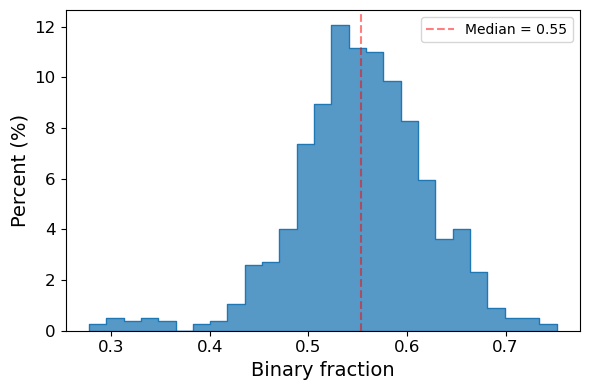

In [19]:
fig, ax= plt.subplots(figsize= (6,4))
sns.histplot(data=df, x='bin_frac_corr', stat='percent', element='step',)
plt.axvline(df.bin_frac_corr.median(), ls='--', c='r', alpha=0.5, label =f'Median = {df.bin_frac_corr.median():.2f}')
#sns.histplot(data=df[df.Av>1], x='bin_frac', stat='percent', element='step', color='blue', fill = False, alpha=0.5)
#sns.histplot(data=df[df.Av<=1], x='bin_frac', stat='percent', element='step', color='orange', fill = False,)

plt.xlabel('Binary fraction', fontdict=font)
plt.ylabel('Percent (%)', fontdict=font)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.legend()
plt.savefig('dist_fb.png',  dpi=300)
plt.show()


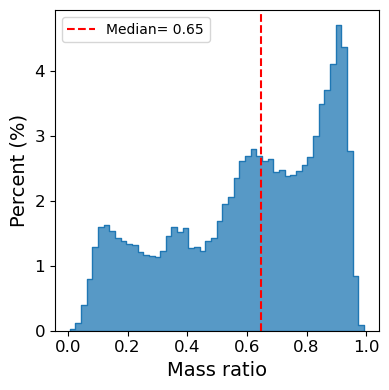

In [20]:
  
fig, ax= plt.subplots(figsize= (4,4))
sns.histplot(x=data[data['q']>0]['q'], stat='percent', element='step',)
plt.axvline(data[data['q']>0]['q'].median(), ls='--', c='r', 
            label = f'Median= {data[data['q']>0]['q'].median():.2f}')

plt.xlabel('Mass ratio', fontdict=font)
plt.ylabel('Percent (%)', fontdict=font)
ax.tick_params(labelsize=labelsize)
plt.tight_layout()
plt.legend(loc='upper left')
#plt.savefig('dist_mass_ratio.png',  dpi=300)
plt.show()

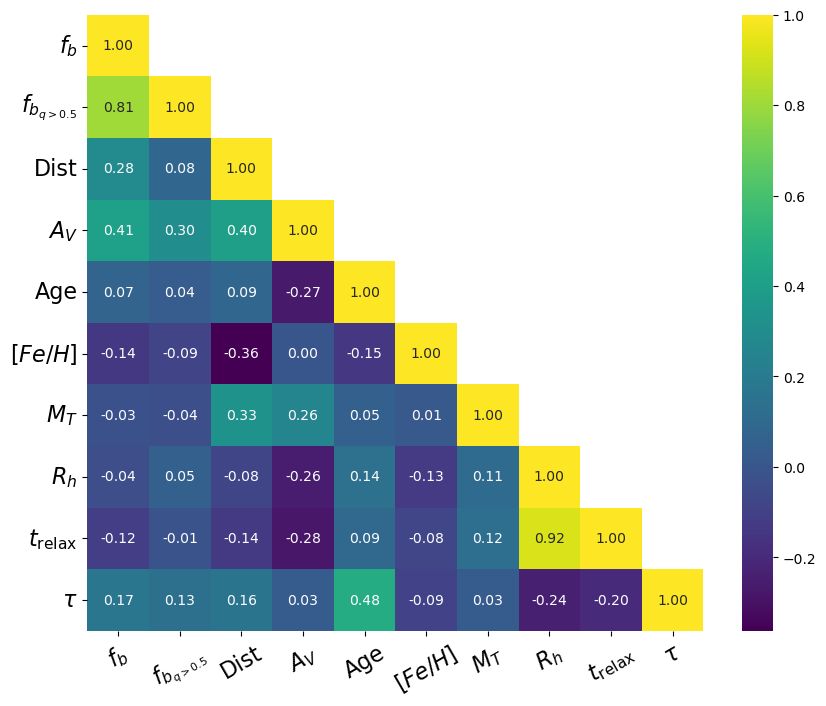

In [26]:
nome_vars = {
    'bin_frac_corr': r'$f_b$',
    'bin_frac_05_corr': r'$f_{b_{q>0.5}}$',
    'dist': r'Dist',
    'Av': r'$A_V$',
    'age': r'Age',
    'FeH': r'[$Fe/H$]',
    'mass_total': r'$M_T$',
    'rh': r'$R_h$',
    't_relax': r'$t_{\mathrm{relax}}$',
    'tau': r'$\tau$',
}

cols = list(nome_vars.keys())
corr = df[cols].corr()
corr.rename(index=nome_vars, columns=nome_vars, inplace=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig = plt.figure(figsize=(10, 8))
cmap = palette  # ou outro colormap desejado

ax = sns.heatmap(corr, mask=mask, annot=True, cmap=cmap, fmt=".2f", square=True, cbar=True,)

for label in ax.get_xticklabels():
    label.set_fontsize(16)
    label.set_rotation(30) 

for label in ax.get_yticklabels():
    label.set_fontsize(16)
    label.set_rotation(0) 

plt.savefig('corr.png',bbox_inches='tight')
plt.show()

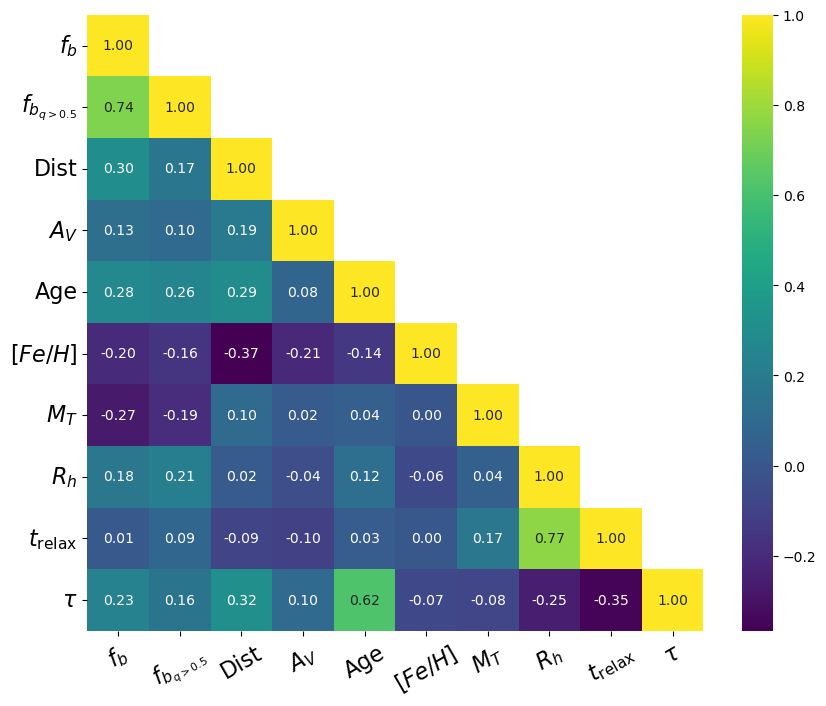

In [25]:
nome_vars = {
    'bin_frac_corr': r'$f_b$',
    'bin_frac_05_corr': r'$f_{b_{q>0.5}}$',
    'dist': r'Dist',
    'Av': r'$A_V$',
    'age': r'Age',
    'FeH': r'[$Fe/H$]',
    'mass_total': r'$M_T$',
    'rh': r'$R_h$',
    't_relax': r'$t_{\mathrm{relax}}$',
    'tau': r'$\tau$',
}

cols = list(nome_vars.keys())
corr = benchmark_subsample[cols].corr(method='kendall')
corr.rename(index=nome_vars, columns=nome_vars, inplace=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig = plt.figure(figsize=(10, 8))
cmap = palette  # ou outro colormap desejado

ax = sns.heatmap(corr, mask=mask, annot=True, cmap=cmap, fmt=".2f", square=True, cbar=True,)

for label in ax.get_xticklabels():
    label.set_fontsize(16)
    label.set_rotation(30) 

for label in ax.get_yticklabels():
    label.set_fontsize(16)
    label.set_rotation(0) 

#plt.savefig('corr.png',bbox_inches='tight')
plt.show()

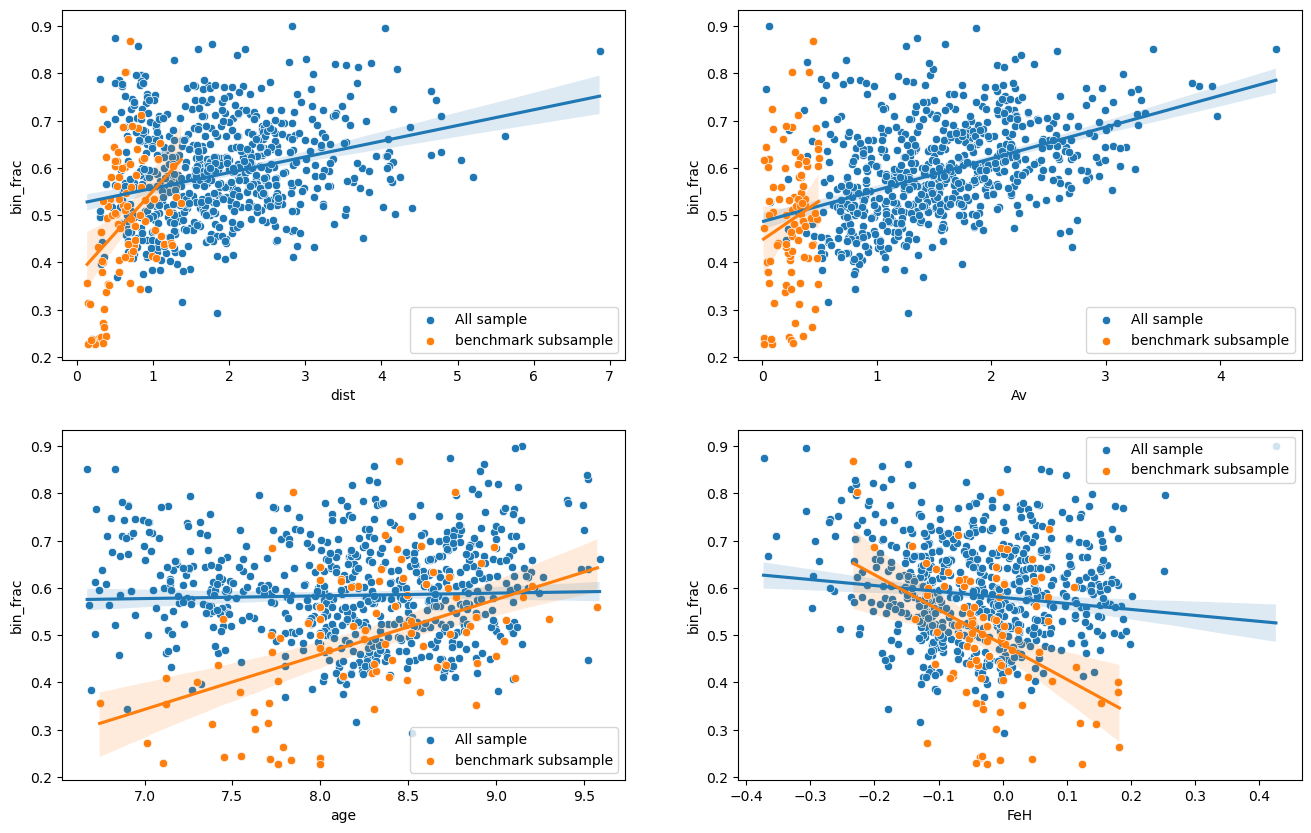

In [111]:
fig, axs = plt.subplots(2,2, figsize=(16,10))

y = 'bin_frac'
xs = ['dist', 'Av', 'age', 'FeH']
i=0
j=0
for x in xs:
    #Amostra total
    sns.scatterplot(data=df, x =x, y=y, ax=axs[i,j],label='All sample')
    sns.regplot(data=df, x = x, y = y, ax = axs[i,j], scatter=False, robust=True)
    
    
    #Benchmark subsample
    sns.scatterplot(data=benchmark_subsample, x =x, y=y, ax=axs[i,j],label='benchmark subsample')
    sns.regplot(data=benchmark_subsample, x = x, y = y, ax = axs[i,j], scatter=False, robust=True)
    
    
    j = j+1
    if j>1:
        j=0
        i = i+1


In [36]:
#Correção da fração de binárias pelo desvio da média de fb na subamostra de referência
mean_bf_bench = benchmark_subsample['bin_frac'].mean()    
mean_bf_all = df['bin_frac'].mean()

0.51